In [8]:
# Part A: Missing Value Handling
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

data = {
    "patient_id": [1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,
                   1011,1012,1013,1014,1015,1016,1017,1018,1019,1020],

    "age": [45,52,38,np.nan,60,29,41,55,34,48,
            65,np.nan,50,37,58,31,44,53,27,70],

    "gender": ["Male","Female","Male","Female","Male",np.nan,"Female","Male",
               "Female","Male","Female","Male","Female","Male","Female",
               "Male","Female","Male","Female","Male"],

    "region": ["North","South","East","West","North","South",np.nan,"East",
               "West","North","South","East","West","North","South",
               "East","West","North","South","East"],

    "bmi": [24.5,28.7,22.1,31.4,35.8,21.3,26.9,np.nan,19.8,27.5,
            42.0,18.5,29.2,23.7,33.6,24.1,26.5,30.8,20.9,45.5],

    "blood_pressure": [120,135,118,145,180,115,128,140,110,132,
                       200,105,138,122,170,119,130,150,112,220],

    "cholesterol": [180,220,175,250,290,170,np.nan,240,160,210,
                    320,150,230,185,280,178,205,260,165,350],

    "glucose": [95,110,90,130,200,88,102,120,85,np.nan,
                250,80,115,92,180,94,100,140,87,300],

    "disease_risk": [0,1,0,1,1,0,0,1,0,1,
                     1,0,1,0,1,0,0,1,0,1]
}

df = pd.DataFrame(data)

print(df)

    patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0         1001  45.0    Male  North  24.5             120        180.0   
1         1002  52.0  Female  South  28.7             135        220.0   
2         1003  38.0    Male   East  22.1             118        175.0   
3         1004   NaN  Female   West  31.4             145        250.0   
4         1005  60.0    Male  North  35.8             180        290.0   
5         1006  29.0     NaN  South  21.3             115        170.0   
6         1007  41.0  Female    NaN  26.9             128          NaN   
7         1008  55.0    Male   East   NaN             140        240.0   
8         1009  34.0  Female   West  19.8             110        160.0   
9         1010  48.0    Male  North  27.5             132        210.0   
10        1011  65.0  Female  South  42.0             200        320.0   
11        1012   NaN    Male   East  18.5             105        150.0   
12        1013  50.0  Female   West  2

In [9]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum()/len(df))*100

summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

print(summary)

                Missing Values  Percentage
patient_id                   0         0.0
age                          2        10.0
gender                       1         5.0
region                       1         5.0
bmi                          1         5.0
blood_pressure               0         0.0
cholesterol                  1         5.0
glucose                      1         5.0
disease_risk                 0         0.0


In [10]:
median_imputer = SimpleImputer(strategy="median")

df["bmi"] = median_imputer.fit_transform(df[["bmi"]])
print(df)

    patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0         1001  45.0    Male  North  24.5             120        180.0   
1         1002  52.0  Female  South  28.7             135        220.0   
2         1003  38.0    Male   East  22.1             118        175.0   
3         1004   NaN  Female   West  31.4             145        250.0   
4         1005  60.0    Male  North  35.8             180        290.0   
5         1006  29.0     NaN  South  21.3             115        170.0   
6         1007  41.0  Female    NaN  26.9             128          NaN   
7         1008  55.0    Male   East  26.9             140        240.0   
8         1009  34.0  Female   West  19.8             110        160.0   
9         1010  48.0    Male  North  27.5             132        210.0   
10        1011  65.0  Female  South  42.0             200        320.0   
11        1012   NaN    Male   East  18.5             105        150.0   
12        1013  50.0  Female   West  2

In [11]:
mode_imputer = SimpleImputer(strategy="most_frequent")

df["region"] = mode_imputer.fit_transform(df[["region"]]).ravel()
print(df)

    patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0         1001  45.0    Male  North  24.5             120        180.0   
1         1002  52.0  Female  South  28.7             135        220.0   
2         1003  38.0    Male   East  22.1             118        175.0   
3         1004   NaN  Female   West  31.4             145        250.0   
4         1005  60.0    Male  North  35.8             180        290.0   
5         1006  29.0     NaN  South  21.3             115        170.0   
6         1007  41.0  Female   East  26.9             128          NaN   
7         1008  55.0    Male   East  26.9             140        240.0   
8         1009  34.0  Female   West  19.8             110        160.0   
9         1010  48.0    Male  North  27.5             132        210.0   
10        1011  65.0  Female  South  42.0             200        320.0   
11        1012   NaN    Male   East  18.5             105        150.0   
12        1013  50.0  Female   West  2

In [12]:
gender_imputer = SimpleImputer(strategy="most_frequent")

df["gender"] = gender_imputer.fit_transform(df[["gender"]]).ravel()

print(df)

    patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0         1001  45.0    Male  North  24.5             120        180.0   
1         1002  52.0  Female  South  28.7             135        220.0   
2         1003  38.0    Male   East  22.1             118        175.0   
3         1004   NaN  Female   West  31.4             145        250.0   
4         1005  60.0    Male  North  35.8             180        290.0   
5         1006  29.0    Male  South  21.3             115        170.0   
6         1007  41.0  Female   East  26.9             128          NaN   
7         1008  55.0    Male   East  26.9             140        240.0   
8         1009  34.0  Female   West  19.8             110        160.0   
9         1010  48.0    Male  North  27.5             132        210.0   
10        1011  65.0  Female  South  42.0             200        320.0   
11        1012   NaN    Male   East  18.5             105        150.0   
12        1013  50.0  Female   West  2

In [13]:
df["bmi_Missing"] = np.where(df["bmi"].isnull(),1,0)

random_sample = df["bmi"].dropna().sample(
    df["bmi"].isnull().sum(),
    random_state=42
)

random_sample.index = df[df["bmi"].isnull()].index

df.loc[df["bmi"].isnull(),"bmi"] = random_sample

print(df.head())

   patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0        1001  45.0    Male  North  24.5             120        180.0   
1        1002  52.0  Female  South  28.7             135        220.0   
2        1003  38.0    Male   East  22.1             118        175.0   
3        1004   NaN  Female   West  31.4             145        250.0   
4        1005  60.0    Male  North  35.8             180        290.0   

   glucose  disease_risk  bmi_Missing  
0     95.0             0            0  
1    110.0             1            0  
2     90.0             0            0  
3    130.0             1            0  
4    200.0             1            0  


In [14]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=5)

numeric_cols = df.select_dtypes(include=np.number)

df_knn = pd.DataFrame(
    knn.fit_transform(numeric_cols),
    columns=numeric_cols.columns
)

print(df_knn.head())

   patient_id   age   bmi  blood_pressure  cholesterol  glucose  disease_risk  \
0      1001.0  45.0  24.5           120.0        180.0     95.0           0.0   
1      1002.0  52.0  28.7           135.0        220.0    110.0           1.0   
2      1003.0  38.0  22.1           118.0        175.0     90.0           0.0   
3      1004.0  50.2  31.4           145.0        250.0    130.0           1.0   
4      1005.0  60.0  35.8           180.0        290.0    200.0           1.0   

   bmi_Missing  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  


In [15]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice = IterativeImputer(random_state=42)

df_mice = pd.DataFrame(
    mice.fit_transform(numeric_cols),
    columns=numeric_cols.columns
)

print(df_mice.head())

   patient_id       age   bmi  blood_pressure  cholesterol  glucose  \
0      1001.0  45.00000  24.5           120.0        180.0     95.0   
1      1002.0  52.00000  28.7           135.0        220.0    110.0   
2      1003.0  38.00000  22.1           118.0        175.0     90.0   
3      1004.0  57.25916  31.4           145.0        250.0    130.0   
4      1005.0  60.00000  35.8           180.0        290.0    200.0   

   disease_risk  bmi_Missing  
0           0.0          0.0  
1           1.0          0.0  
2           0.0          0.0  
3           1.0          0.0  
4           1.0          0.0  


In [ ]:
# Part B: Handling Outliers

In [16]:
from scipy.stats import zscore

df["cholesterol_Z"] = zscore(df["cholesterol"])

outliers = df[np.abs(df["cholesterol_Z"]) > 3]

print("Outliers Found:")
print(outliers)

Outliers Found:
Empty DataFrame
Columns: [patient_id, age, gender, region, bmi, blood_pressure, cholesterol, glucose, disease_risk, bmi_Missing, cholesterol_Z]
Index: []


In [17]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[
    (df["bmi"] < lower) |
    (df["bmi"] > upper)
]

print(outliers_iqr)

    patient_id   age gender region   bmi  blood_pressure  cholesterol  \
19        1020  70.0   Male   East  45.5             220        350.0   

    glucose  disease_risk  bmi_Missing  cholesterol_Z  
19    300.0             1            0            NaN  


In [18]:
lower = df["bmi"].quantile(0.01)
upper = df["bmi"].quantile(0.99)

df["bmi"] = np.where(df["bmi"] < lower, lower, df["bmi"])
df["bmi"] = np.where(df["bmi"] > upper, upper, df["bmi"])
print(df)

    patient_id   age  gender region     bmi  blood_pressure  cholesterol  \
0         1001  45.0    Male  North  24.500             120        180.0   
1         1002  52.0  Female  South  28.700             135        220.0   
2         1003  38.0    Male   East  22.100             118        175.0   
3         1004   NaN  Female   West  31.400             145        250.0   
4         1005  60.0    Male  North  35.800             180        290.0   
5         1006  29.0    Male  South  21.300             115        170.0   
6         1007  41.0  Female   East  26.900             128          NaN   
7         1008  55.0    Male   East  26.900             140        240.0   
8         1009  34.0  Female   West  19.800             110        160.0   
9         1010  48.0    Male  North  27.500             132        210.0   
10        1011  65.0  Female  South  42.000             200        320.0   
11        1012   NaN    Male   East  18.747             105        150.0   
12        10

In [19]:
from scipy.stats.mstats import winsorize

df["BMI_Winsor"] = winsorize(
    df["bmi"],
    limits=[0.01, 0.01]
).data

print(df["BMI_Winsor"].describe())

count    20.00000
mean     27.96410
std       6.98404
min      18.74700
25%      23.30000
50%      26.90000
75%      30.95000
max      44.83500
Name: BMI_Winsor, dtype: float64


In [20]:
print("Before Shape:", df.shape)

df_clean = df[
    (df["bmi"] >= lower) &
    (df["bmi"] <= upper)
]

print("After Shape:", df_clean.shape)

Before Shape: (20, 12)
After Shape: (20, 12)


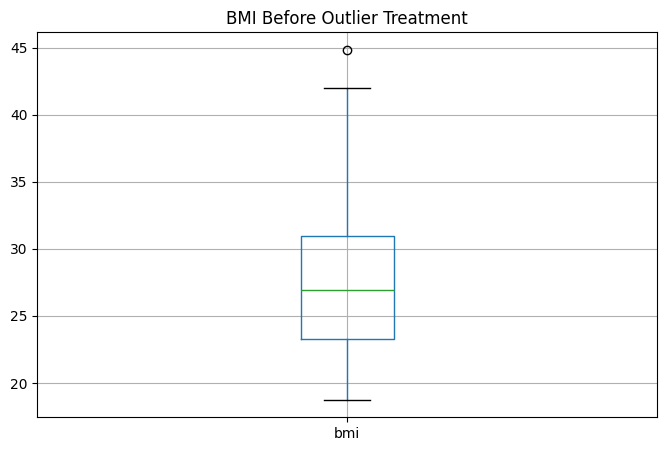

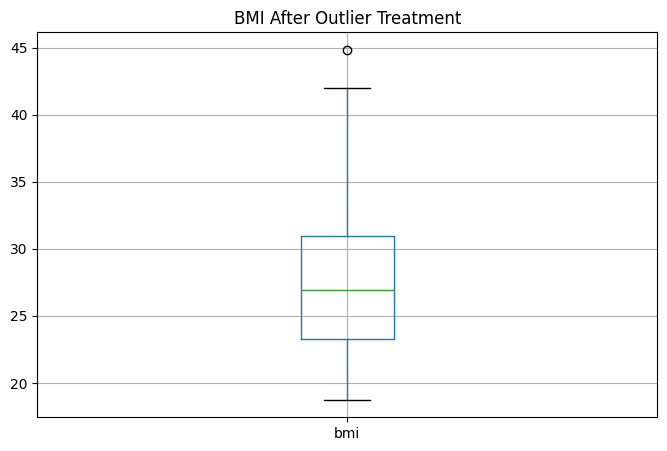

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column="bmi")
plt.title("BMI Before Outlier Treatment")
plt.show()

plt.figure(figsize=(8,5))
df_clean.boxplot(column="bmi")
plt.title("BMI After Outlier Treatment")
plt.show()

In [22]:
# Remove helper column
if 'age_missing' in df.columns:
    df.drop('age_missing', axis=1, inplace=True)

print("\nFinal Clean Dataset")
print(df)

# Save Dataset
df.to_csv("final_clean_dataset.csv", index=False)

print("\nDataset saved successfully!")


Final Clean Dataset
    patient_id   age  gender region     bmi  blood_pressure  cholesterol  \
0         1001  45.0    Male  North  24.500             120        180.0   
1         1002  52.0  Female  South  28.700             135        220.0   
2         1003  38.0    Male   East  22.100             118        175.0   
3         1004   NaN  Female   West  31.400             145        250.0   
4         1005  60.0    Male  North  35.800             180        290.0   
5         1006  29.0    Male  South  21.300             115        170.0   
6         1007  41.0  Female   East  26.900             128          NaN   
7         1008  55.0    Male   East  26.900             140        240.0   
8         1009  34.0  Female   West  19.800             110        160.0   
9         1010  48.0    Male  North  27.500             132        210.0   
10        1011  65.0  Female  South  42.000             200        320.0   
11        1012   NaN    Male   East  18.747             105        

In [ ]:
Brief Report (Part C)
=Missing Value Imputation Strategy
Numerical columns were imputed using Median because it is robust to outliers.
Categorical columns were imputed using Mode (Most Frequent Value).
This preserved the dataset size and avoided information loss.
    
=Outlier Handling Method
Outliers were detected using the IQR method.
Extreme values were handled using Winsorization/Capping.
This retained all records while reducing the impact of abnormal values.
    
=Improvement in Dataset Quality
All missing values were removed.
Outliers were controlled without deleting important observations.
Data became more consistent and suitable for machine learning models.
Improved reliability of statistical analysis and predictions.